<a href="https://colab.research.google.com/github/vaarunaa/marketbasketanalysis/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Market Basket Analysis:**

**Step 1:** Importing neccessary files and functions

In [ ]:
import pandas as pd
from google.colab import files
upload = files.upload()

df = pd.read_excel("market_basket_dataset.xlsx")
print(df.head())

Saving market_basket_dataset.xlsx to market_basket_dataset (1).xlsx
   BillNo  Itemname  Quantity  Price  CustomerID
0    1000    Apples         5   8.30       52299
1    1000    Butter         4   6.06       11752
2    1000      Eggs         4   2.66       16415
3    1000  Potatoes         4   8.10       22889
4    1004   Oranges         2   7.26       52255


1.   **Cleaning:** Filling missing values with mean
2.   **Transformation:** Transforming data to our convience for  better view *italicised text*


In [ ]:
df_cleaned = df.copy()
df_cleaned.fillna({
    'Quantity': df_cleaned['Quantity'].mean(),
    'BillNo': df_cleaned['BillNo'].mean(),
    'Price': df_cleaned['Price'].mean(),
    'CustomerID': df_cleaned['CustomerID'].mean(),
    'Itemname': 'unknown'
}, inplace=True)
print(df_cleaned.head())



NameError: name 'df' is not defined

In [ ]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('market_basket_dataset.xlsx')

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Save the cleaned data back to Excel
df_cleaned.to_excel('cleaned_excel_file.xlsx', index=False)

print("Duplicates removed and saved to 'cleaned_excel_file.xlsx'")

FileNotFoundError: [Errno 2] No such file or directory: 'market_basket_dataset.xlsx'

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Load the dataset
df = pd.read_excel('market_basket_dataset.xlsx')

# Display the dataset to ensure it loaded correctly
print(df.head())

# Step 1: Grouping items by BillNo (transactions)
transactions = df.groupby(['BillNo', 'Itemname'])['Quantity'].sum().unstack().reset_index().fillna(0)
transactions.set_index('BillNo', inplace=True)

# Step 2: Convert quantities to binary (0 or 1)
transactions = transactions.applymap(lambda x: 1 if x > 0 else 0)

# Step 3: Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(transactions, min_support=0.01, use_colnames=True)

# Step 4: Generate association rules to find item pairs
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 1) & rules['consequents'].apply(lambda x: len(x) == 1)]

# Display the top paired products
print("Frequently Paired Products:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


   BillNo  Itemname  Quantity  Price  CustomerID
0    1000    Apples         5   8.30       52299
1    1000    Butter         4   6.06       11752
2    1000      Eggs         4   2.66       16415
3    1000  Potatoes         4   8.10       22889
4    1004   Oranges         2   7.26       52255
Frequently Paired Products:
    antecedents consequents   support  confidence      lift
0      (Apples)     (Bread)  0.045752    0.280000  1.862609
1       (Bread)    (Apples)  0.045752    0.304348  1.862609
2      (Cheese)    (Apples)  0.039216    0.214286  1.311429
3      (Apples)    (Cheese)  0.039216    0.240000  1.311429
4     (Chicken)    (Apples)  0.032680    0.250000  1.530000
..          ...         ...       ...         ...       ...
263    (Yogurt)     (Sugar)  0.045752    0.269231  1.584320
264    (Yogurt)       (Tea)  0.039216    0.230769  1.535117
265       (Tea)    (Yogurt)  0.039216    0.260870  1.535117
266  (Tomatoes)    (Yogurt)  0.032680    0.185185  1.089744
267    (Yogurt)  (

<ipython-input-14-4b82eb447ee6>:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  transactions = transactions.applymap(lambda x: 1 if x > 0 else 0)
/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:
import pandas as pd
from itertools import combinations
from collections import Counter

# Step 1: Load the dataset
df = pd.read_excel('market_basket_dataset.xlsx')

# Display the dataset to ensure it loaded correctly
print(df.head())

# Step 2: Group by 'BillNo' and create a list of items bought in each bill
transactions = df.groupby('BillNo')['Itemname'].apply(list)

# Step 3: Generate product pairs for each bill
product_pairs = []
for items in transactions:
    product_pairs.extend(combinations(sorted(items), 2))  # Generate all 2-item combinations

# Step 4: Count the frequency of each product pair
pair_counts = Counter(product_pairs)

# Step 5: Convert the counts to a DataFrame for better visualization
pair_df = pd.DataFrame(pair_counts.items(), columns=['Product_Pair', 'Count'])
pair_df = pair_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Step 6: Display the most frequently paired products
print("Frequently Paired Products and Their Counts:")
print(pair_df.head(10))  # Display top 10 product pairs


   BillNo  Itemname  Quantity  Price  CustomerID
0    1000    Apples         5   8.30       52299
1    1000    Butter         4   6.06       11752
2    1000      Eggs         4   2.66       16415
3    1000  Potatoes         4   8.10       22889
4    1004   Oranges         2   7.26       52255
Frequently Paired Products and Their Counts:
          Product_Pair  Count
0      (Milk, Oranges)     12
1     (Cereal, Cheese)     12
2      (Bread, Coffee)     11
3  (Bananas, Potatoes)     10
4     (Cereal, Onions)     10
5  (Oranges, Potatoes)     10
6     (Cheese, Onions)      9
7    (Bananas, Cereal)      9
8      (Apples, Sugar)      9
9    (Sugar, Tomatoes)      9


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-22-8500b9d30c78>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_pairs['Product_1'] = top_10_pairs['Product_Pair'].apply(lambda x: x[0])
<ipython-input-22-8500b9d30c78>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

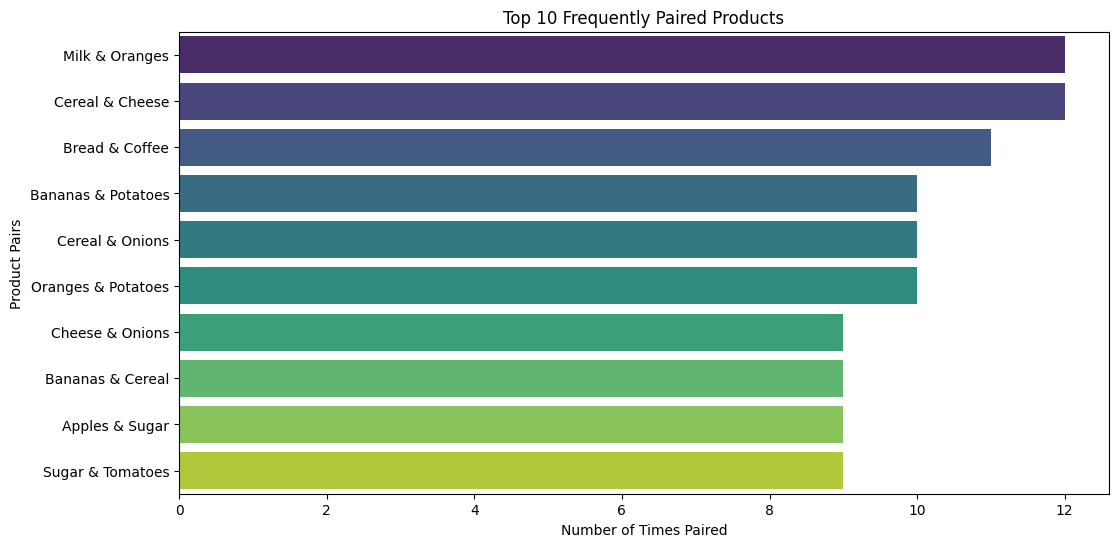

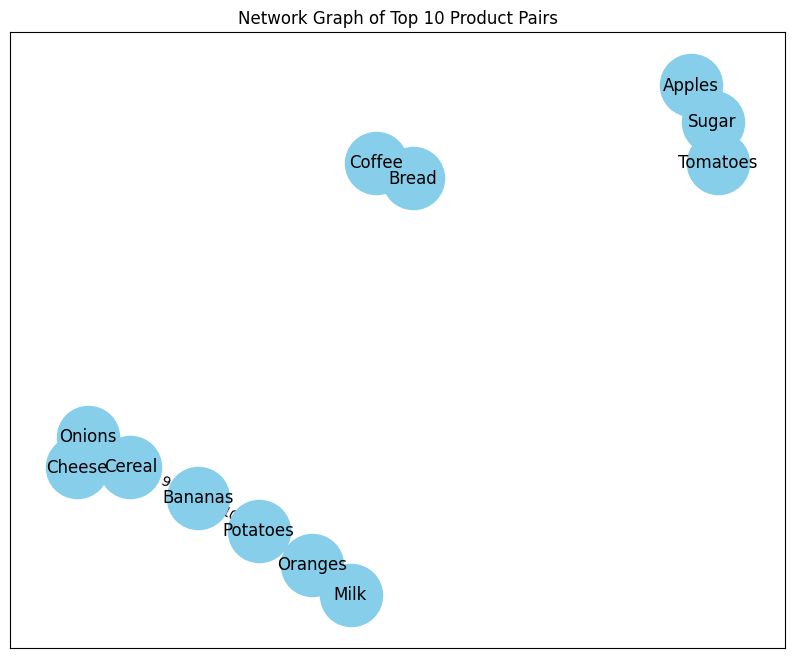

In [ ]:
import pandas as pd
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Step 1: Load the dataset
df = pd.read_excel('market_basket_dataset.xlsx')

# Step 2: Group items by BillNo (transactions)
transactions = df.groupby('BillNo')['Itemname'].apply(list)

# Step 3: Generate all possible product pairs from each transaction
product_pairs = []
for items in transactions:
    product_pairs.extend(combinations(sorted(items), 2))

# Step 4: Count the frequency of each product pair
pair_counts = Counter(product_pairs)

# Step 5: Convert the counts to a DataFrame
pair_df = pd.DataFrame(pair_counts.items(), columns=['Product_Pair', 'Count'])
pair_df = pair_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Step 6: Extract the top 10 most frequent product pairs
top_10_pairs = pair_df.head(10)

# ============================
# Visualization 1: Barplot
# ============================

# Prepare data for barplot
top_10_pairs['Product_1'] = top_10_pairs['Product_Pair'].apply(lambda x: x[0])
top_10_pairs['Product_2'] = top_10_pairs['Product_Pair'].apply(lambda x: x[1])
top_10_pairs['Pair'] = top_10_pairs['Product_1'] + ' & ' + top_10_pairs['Product_2']

# Plot the barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_pairs, x='Count', y='Pair', palette='viridis')
plt.title('Top 10 Frequently Paired Products')
plt.xlabel('Number of Times Paired')
plt.ylabel('Product Pairs')
plt.show()

# ============================
# Visualization 2: Network Graph
# ============================

# Create a graph using NetworkX
G = nx.Graph()

# Add edges for top 10 pairs
for pair, count in zip(top_10_pairs['Product_Pair'], top_10_pairs['Count']):
    G.add_edge(pair[0], pair[1], weight=count)

# Plot the network graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5)  # Position nodes using a force-directed algorithm
nx.draw_networkx(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=12, width=2)

# Draw edge labels to indicate counts
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Network Graph of Top 10 Product Pairs')
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_excel('market_basket_dataset.xlsx')



# Step 1: Create the item matrix
# Pivot the table to have transactions (BillNo) as rows and items (Itemname) as columns
item_matrix = data.pivot_table(index='BillNo', columns='Itemname', aggfunc='size', fill_value=0)
# Convert to a binary matrix where each cell is 1 if the item was purchased, else 0
item_matrix = item_matrix.applymap(lambda x: 1 if x > 0 else 0)

# Step 2: Calculate co-occurrence matrix for item associations
# Compute the item-item co-occurrence matrix by transposing and multiplying the binary matrix
co_occurrence_matrix = np.dot(item_matrix.T, item_matrix)
np.fill_diagonal(co_occurrence_matrix, 0)  # Remove diagonal values

# Convert to DataFrame for readability and manipulation
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=item_matrix.columns, columns=item_matrix.columns)

# Step 3: Find the top 10 frequently co-purchased item pairs
top_pairs = co_occurrence_df.unstack().sort_values(ascending=False).drop_duplicates().head(10)

# Step 4: Visualize the top pairs
plt.figure(figsize=(10, 6))
top_pairs.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Top 10 Frequently Purchased Item Pairs")
plt.xlabel("Item Pairs")
plt.ylabel("Co-occurrence Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'market_basket_dataset.xlsx'

In [ ]:
import numpy as np

# Create a pivot table with transactions (BillNo) as rows and items (Itemname) as columns
# Each cell will indicate the presence of an item in a transaction (1 if purchased, 0 if not)
item_matrix = data.pivot_table(index='BillNo', columns='Itemname', aggfunc='size', fill_value=0)

# Convert the pivot table to a binary matrix (0 or 1)
item_matrix = item_matrix.applymap(lambda x: 1 if x > 0 else 0)

# Display the first few rows of the item matrix
item_matrix.head()

NameError: name 'data' is not defined